# Лабораторная работа 1. Линейная регрессия и факторный анализ

### Описание работы
**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Постановка задачи:** 

Провести обучение модели линейной регрессии на датасете:

1. Загрузить датасет
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной
3. Провести предобработку данных: удалить пропущенные значения
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности.
5. Построить регрессионные модели (линейная и гребневая). Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).
7. Повторить шаг 5 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

### Ход работы

**О датасете:** Этот набор данных содержит различные характеристики автомобилей, включая год выпуска, цену продажи, пробег, тип топлива, тип продавца, тип трансмиссии, количество предыдущих владельцев, пробег и характеристики двигателя. Эти характеристики дают ценную информацию о факторах, влияющих на цены автомобилей, и могут быть использованы для разработки прогнозных моделей оценки цены продажи автомобилей.

#### 1. Загрузить датасет

> Загрузим данные из файла и выведим первые пять строк таблицы.

In [2]:
import pandas as pd
df = pd.read_csv("datasets/cardekho.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


Каждая единица данных — это отдельный автомобиль с информацией о:
- name — название/модель автомобиля;
- year — год выпуска;
- selling_price — цена продажи;
- km_driven — пробег;
- fuel — тип топлива;
- seller_type — тип продавца (частник или дилер);
- transmission — тип коробки передач;
- owner — количество предыдущих владельцев;
- mileage — расход топлива;
- engine — объем двигателя;
- max_power — максимальная мощность;
- seats — количество мест.

Целевой переменной является **selling_price** — цена продажи. Именно ее и нужно научиться предсказывать.

#### 2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. Провести предобработку данных: удалить пропущенные значения

> Посмотрим, с каким типом переменных предстоит работать.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      7913 non-null   object 
 11  seats          7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


Среди них есть как количественные переменные (например, год выпуска, цена продажи, пробег, расход топлива, объём двигателя, количество мест), так и категориальные (например, название автомобиля, тип топлива, тип продавца, тип коробки передач, количество владельцев).

> Заменяет нули и пропуски в столбцах mileage и max_power на медиану.

In [4]:
import numpy as np
cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce') 


> Выведим основные статистические показатели

In [5]:
df.describe().round(2)

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,8128.00,8128.00,8128.00,7907.00,7907.00,7912.00,7907.00
mean,2013.80,638271.81,69819.51,19.42,1458.63,91.52,5.42
std,4.04,806253.40,56550.55,4.04,503.92,35.82,0.96
min,1983.00,29999.00,1.00,0.00,624.00,0.00,2.00
25%,2011.00,254999.00,35000.00,16.78,1197.00,68.05,5.00
50%,2015.00,450000.00,60000.00,19.30,1248.00,82.00,5.00
75%,2017.00,675000.00,98000.00,22.32,1582.00,102.00,5.00
max,2020.00,10000000.00,2360457.00,42.00,3604.00,400.00,14.00


> Посчитаем пропущенные значения

In [6]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        216
seats            221
dtype: int64

> Заменяет нули и пропуски в столбцах на медиану.

In [7]:
df['mileage'] = df['mileage'].replace(0.00,np.nan)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')  
df['mileage'] = df['mileage'].fillna(df['mileage'].median())  

df['max_power'] = df['max_power'].replace(' ', np.nan)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')  
df['max_power'] = df['max_power'].fillna(df['max_power'].median()) 

df['engine'] = df['engine'].replace(' ', np.nan)
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')  
df['engine'] = df['engine'].fillna(df['engine'].median())

df['seats'] = df['seats'].replace(' ', np.nan)
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')  
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

> Визуализирование распределение признаков и целевой переменной

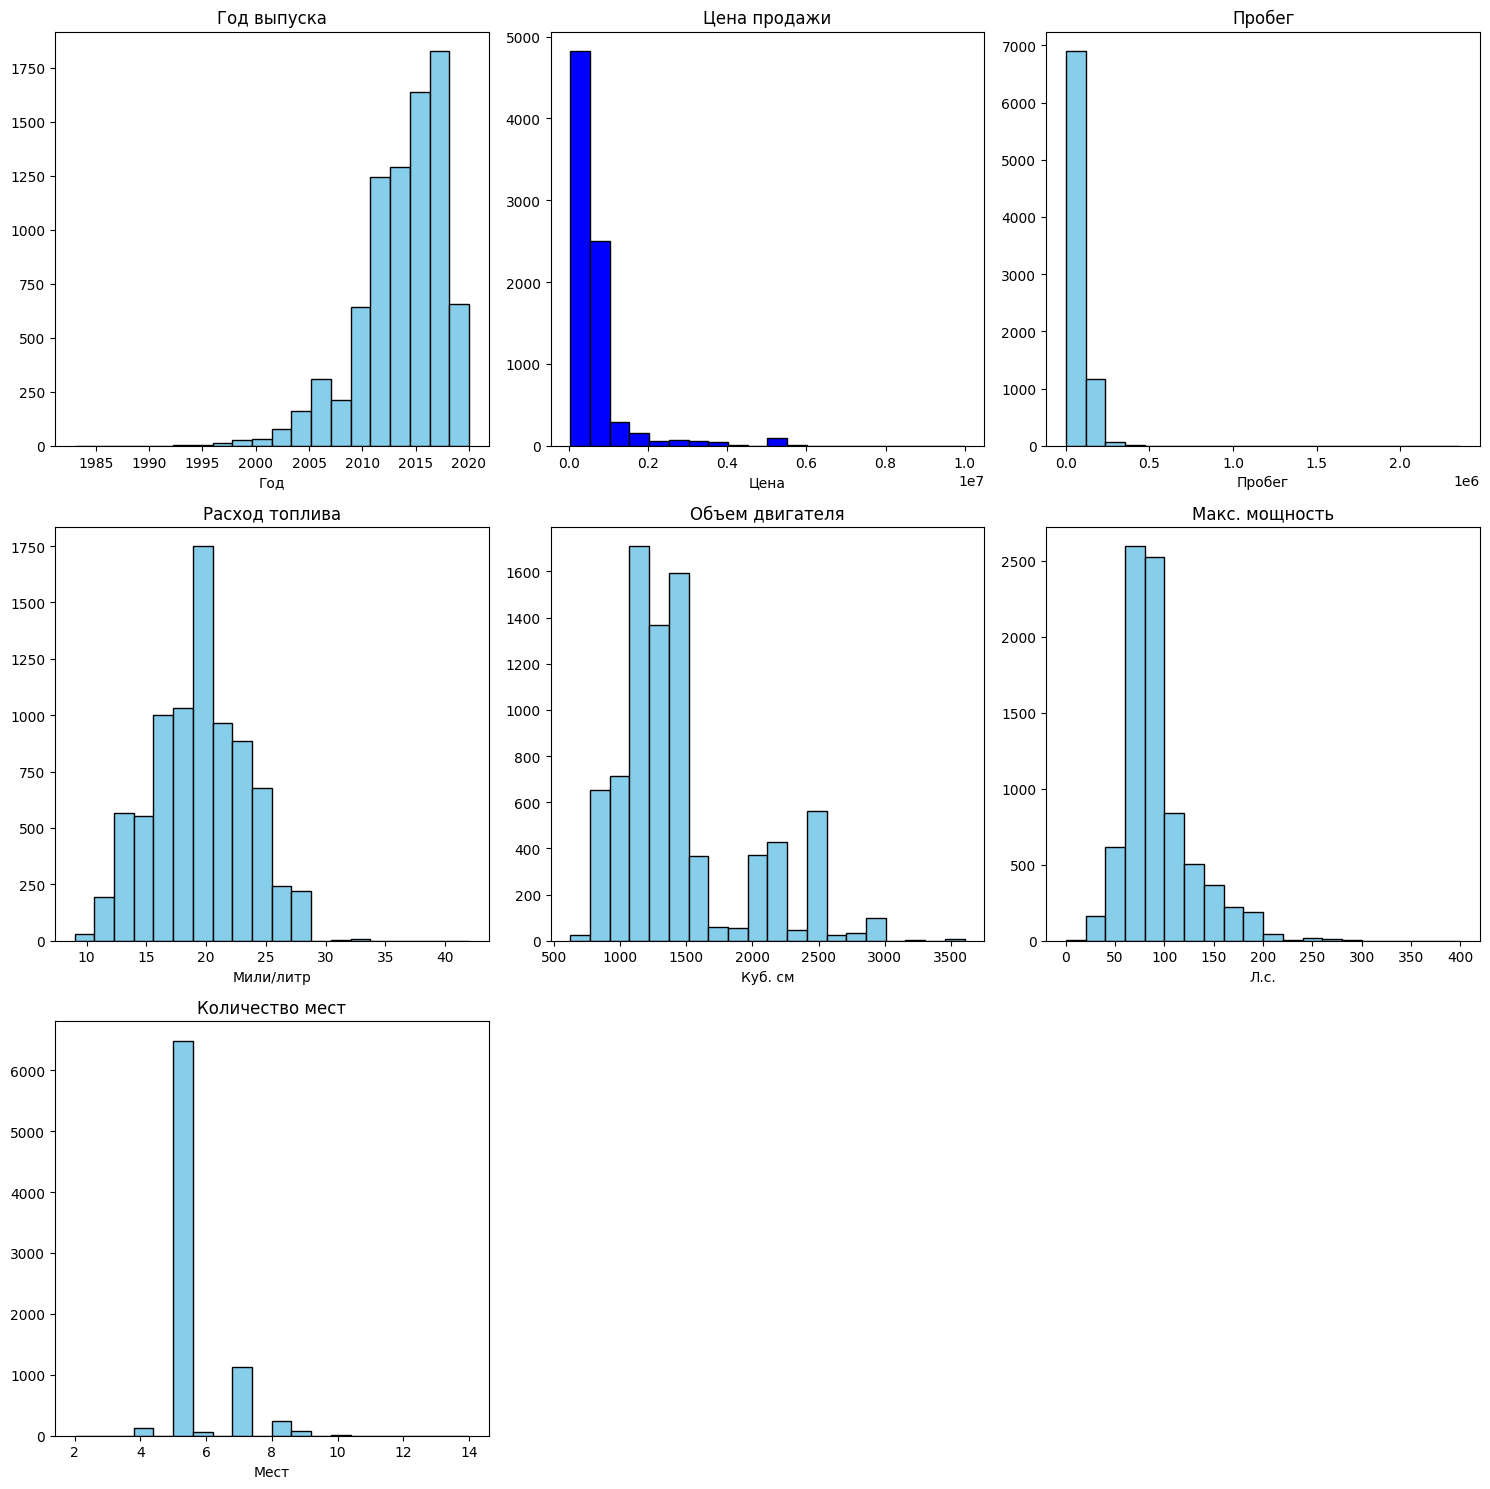

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

axes[0, 0].hist(df['year'], color='skyblue', edgecolor='black', bins=20)
axes[0, 0].set_title("Год выпуска")
axes[0, 0].set_xlabel("Год")


axes[0, 1].hist(df['selling_price'], color='blue', edgecolor='black', bins=20)
axes[0, 1].set_title("Цена продажи")
axes[0, 1].set_xlabel("Цена")


axes[0, 2].hist(df['km_driven'], color='skyblue', edgecolor='black', bins=20)
axes[0, 2].set_title("Пробег")
axes[0, 2].set_xlabel("Пробег")


axes[1, 0].hist(df['mileage'], color='skyblue', edgecolor='black', bins=20)
axes[1, 0].set_title("Расход топлива")
axes[1, 0].set_xlabel("Мили/литр")


axes[1, 1].hist(df['engine'], color='skyblue', edgecolor='black', bins=20)
axes[1, 1].set_title("Объем двигателя")
axes[1, 1].set_xlabel("Куб. см")

axes[1, 2].hist(df['max_power'], color='skyblue', edgecolor='black', bins=20)
axes[1, 2].set_title("Макс. мощность")
axes[1, 2].set_xlabel("Л.с.")

axes[2, 0].hist(df['seats'], color='skyblue', edgecolor='black', bins=20)
axes[2, 0].set_title("Количество мест")
axes[2, 0].set_xlabel("Мест")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)
plt.tight_layout()
plt.show()

#### 3. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности.

>  Далее посторим матрицу корреляций

In [9]:
df[cols].corr().round(2)

,year,selling_price,km_driven,mileage,engine,max_power,seats
year,1.00,0.41,-0.42,0.32,0.04,0.22,0.01
selling_price,0.41,1.00,-0.23,-0.13,0.46,0.75,0.05
km_driven,-0.42,-0.23,1.00,-0.18,0.20,-0.04,0.22
mileage,0.32,-0.13,-0.18,1.00,-0.59,-0.38,-0.47
engine,0.04,0.46,0.20,-0.59,1.00,0.70,0.61
max_power,0.22,0.75,-0.04,-0.38,0.70,1.00,0.19
seats,0.01,0.05,0.22,-0.47,0.61,0.19,1.00


<Axes: >

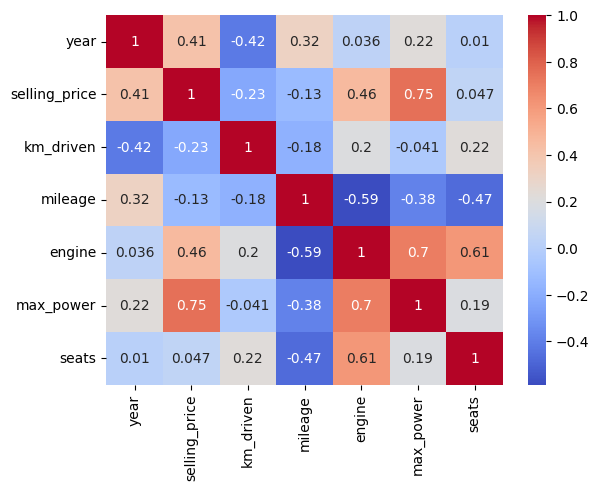

In [10]:
import seaborn as sns

sns.heatmap(df[cols].corr(), annot=True,cmap="coolwarm")

Корреляционный анализ показал, что наибольшая положительная связь с ценой продажи автомобиля наблюдается у признаков максимальная мощность двигателя (max_power, **0.75**) и объём двигателя (engine, **0.46**), а также у года выпуска (year, **0.41**). Пробег (km_driven) и расход топлива (mileage) имеют отрицательную корреляцию с ценой, что соответствует ожиданиям: чем больше пробег и расход, тем ниже стоимость. Также отмечается сильная взаимосвязь между признаками engine и max_power (**0.70**), что важно учитывать при построении моделей из-за возможной мультиколлинеарности. Остальные признаки имеют слабую или умеренную корреляцию с целевой переменной.

> Далее рассчитаем VIF-коэффициента

In [11]:
from matplotlib import axis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df[cols].drop('selling_price', axis=1))
VIFs = pd.DataFrame()
VIFs['Variable'] = X.columns
VIFs['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(VIFs)

    Variable            VIF
0      const  404235.215225
1       year       1.659408
2  km_driven       1.349082
3    mileage       2.003869
4     engine       4.188902
5  max_power       2.754061
6      seats       2.117025


Проверка через фактор инфляции дисперсии (VIF) подтверждает выводы из корреляционной матрицы. Значения VIF для большинства переменных находятся в пределах от 1 до 2, что говорит об их относительной независимости. Однако показатель для engine равен 4.19, а для max_power — 2.75, что указывает на умеренную мультиколлинеарность между этими переменными

#### 4. Построить регрессионные модели (линейная и гребневая). Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

> После того, как мы собрали достаточно данных о взаимосвязи переменных, мы можем начать отбор наиболее значимых признаков (feature selection) и создание или выделение новых (feature extraction).

In [21]:
X = df[['year','km_driven','mileage', 'engine', 'max_power', 'seats']]
Y = df[['selling_price']]

df[['selling_price']]

,selling_price
0,450000
1,370000
2,158000
3,225000
4,130000
...,...
8123,320000
8124,135000
8125,382000
8126,290000


Теперь, когда мы загрузили, обработали и исследовали данные, а также отобрали наиболее значимые признаки, мы готовы к обучению модели. 

> Вначале разобьем данные на обучающую и тестовую выборки.

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


##### Линейная регрессия

> Обучим модель и сделаем прогноз.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_percentage_error
model = LinearRegression()
cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')  
model.fit(X_train,Y_train)

print(f"Результаты кросс-валидации (R2): \n{cv_scores}")

y_pred = model.predict(X_test)
print(f"Предсказанные значения: \n{y_pred[:5].round(2)}")

LinearRMSE = root_mean_squared_error(Y_test, y_pred)
LinearR2 = r2_score(Y_test, y_pred)
LinearMAPE = mean_absolute_percentage_error(Y_test, y_pred)
print('RMSE:', LinearRMSE)
print('R2:', LinearR2)
print('MAPE:', LinearMAPE)

Результаты кросс-валидации (R2): 
[0.6471057  0.63790458 0.61371877 0.64561244 0.59350198]
Предсказанные значения: 
[[296356.54]
 [984778.84]
 [502003.08]
 [407337.22]
 [382975.08]]
RMSE: 474711.5691310359
R2: 0.6562068296728334
MAPE: 0.7790357369166688


##### Гребневая регрессия

In [15]:
from sklearn.linear_model import Ridge
model_ridge = Ridge()
cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')  
model_ridge.fit(X_train,Y_train)

print(f"Результаты кросс-валидации (R2): \n{cv_scores}")

y_pred = model_ridge.predict(X_test)
print(f"Предсказанные значения: \n{y_pred[:5].round(2)}")
RidgeRMSE = root_mean_squared_error(Y_test, y_pred)
RidgeR2 = r2_score(Y_test, y_pred)
RidgeMAPE = mean_absolute_percentage_error(Y_test, y_pred)
print('RMSE:', RidgeRMSE)
print('R2:', RidgeR2)
print('MAPE:', RidgeMAPE)

Результаты кросс-валидации (R2): 
[0.6471057  0.63790458 0.61371877 0.64561244 0.59350198]
Предсказанные значения: 
[296352.01 984789.69 501996.48 407335.27 382973.4 ]
RMSE: 474711.37871841877
R2: 0.65620710547207
MAPE: 0.7790302782015024


#### 5. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

> Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

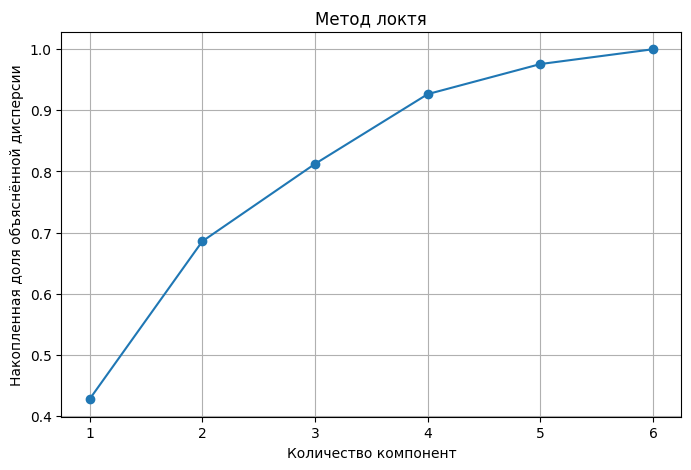

array([0.42730056, 0.68562289, 0.81238124, 0.92655367, 0.97575865,
       1.        ])

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_train_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-')
plt.title('Метод локтя')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля объяснённой дисперсии')
plt.grid(True)
plt.show()
explained_variance


На графике метода локтя видно, что после добавления четвёртой главной компоненты накопленная доля объяснённой дисперсии достигает 0,92 (92%). Это означает, что четыре компоненты сохраняют почти всю вариацию исходных данных, а последующие компоненты дают лишь незначительный прирост информации. Поэтому для дальнейшего анализа и визуализации мы оставляем четыре главные компоненты, что позволяет существенно сократить размерность данных без потери информации

#### 6. Повторить шаг 4 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

##### Линейная регрессия

In [17]:
new_pca = PCA(n_components=4)
X_train_pca = new_pca.fit_transform(X_train_scaled)
print(X_train_pca.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X_train_pca, Y, test_size=0.2, random_state=42)


model = LinearRegression()
cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')
model.fit(X_train, Y_train)

print(f"Результаты кросс-валидации (R²): {cv_scores}")

y_pred = model.predict(X_test)

print(y_pred[:5].round(2))
LinearRMSE_PCA = root_mean_squared_error(Y_test, y_pred)
LinearR2_PCA = r2_score(Y_test, y_pred)
LinearMAPE_PCA = mean_absolute_percentage_error(Y_test, y_pred)
print('RMSE:', LinearRMSE_PCA)
print('R2:', LinearR2_PCA)
print('MAPE:', LinearMAPE_PCA)

(8128, 4)
Результаты кросс-валидации (R²): [0.63025609 0.62732073 0.60949471 0.63497727 0.59394732]
[[261770.74]
 [928655.6 ]
 [538979.17]
 [364072.04]
 [387567.51]]
RMSE: 481596.85324546933
R2: 0.6461616557782053
MAPE: 0.8120593065930454


##### Гребневая регрессия

In [ ]:
new_pca = PCA(n_components=4)
X_train_pca = new_pca.fit_transform(X_train_scaled)
print(X_train_pca.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X_train_pca, Y, test_size=0.2, random_state=42)


model = Ridge()
cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')
model.fit(X_train, Y_train)

print(f"Результаты кросс-валидации (R²): {cv_scores}")

y_pred = model.predict(X_test)

print(y_pred[:5].round(2))
RidgeRMSE_PCA = root_mean_squared_error(Y_test, y_pred)
RidgeR2_PCA = r2_score(Y_test, y_pred)
RidgeMAPE_PCA = mean_absolute_percentage_error(Y_test, y_pred)
print('RMSE:', RidgeRMSE_PCA)
print('R2:', RidgeR2_PCA)
print('MAPE:', RidgeMAPE_PCA)

NameError: name 'PCA' is not defined

##### Сравнительный анализ

In [19]:
results = pd.DataFrame({
    'Модель': [
        'Линейная регрессия (без PCA)',
        'Гребневая регрессия (без PCA)',
        'Линейная регрессия (с PCA)',
        'Гребневая регрессия (с PCA)'
    ],
    'RMSE': [
        LinearRMSE,
        RidgeRMSE,
        LinearRMSE_PCA,
        RidgeRMSE_PCA
    ],
    'MAPE': [
        LinearMAPE,
        RidgeMAPE,
        LinearMAPE_PCA,
        RidgeMAPE_PCA
    ],
    'R2': [
        LinearR2,
        RidgeR2,
        LinearR2_PCA,
        RidgeR2_PCA
    ]
})

print('\nСравнительная таблица метрик качества моделей:')
print(results)


Сравнительная таблица метрик качества моделей:
                          Модель           RMSE      MAPE        R2
0   Линейная регрессия (без PCA)  474711.569131  0.779036  0.656207
1  Гребневая регрессия (без PCA)  474711.378718  0.779030  0.656207
2     Линейная регрессия (с PCA)  481596.853245  0.812059  0.646162
3    Гребневая регрессия (с PCA)  481599.020685  0.811942  0.646158


Сравнение представленных моделей позволяет увидеть, что применение метода главных компонент (PCA) не привело к улучшению качества предсказаний, а даже немного ухудшило результаты. Без использования PCA как линейная, так и гребневая регрессии показывают практически одинаковые значения метрик, что говорит о том, что добавление регуляризации почти не изменило структуру зависимостей и не оказало заметного эффекта на переобучение.

Значения RMSE для моделей без PCA составляют около 474 711, что несколько ниже, чем у моделей с PCA (порядка 481 600). Это означает, что предсказания моделей без снижения размерности точнее. Аналогично, значение MAPE (средняя относительная ошибка) увеличилось после применения PCA — с 0.779 до 0.812, то есть ошибки в процентах стали выше. Коэффициент детерминации R² также снизился с 0.656 до 0.646, что указывает на небольшое уменьшение доли объяснённой вариации целевой переменной.

Таким образом, можно сделать вывод, что в данной задаче метод главных компонент не улучшил модель, поскольку исходные признаки не содержали сильной избыточности или шума, а мультиколлинеарность была умеренной и не мешала обучению. Линейная и гребневая регрессии без PCA работают практически одинаково и дают наилучшие результаты по всем показателям качества.